In [1]:
import numpy as np
import time
from dataclasses import dataclass
import pandas as pd 
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


In [2]:
##TO ZOSTAJE, GIT
full_R = np.load("../data/processed/R_dataset_full.npz", allow_pickle=True)
X_full_R  = full_R["X"]
K0_full_R = full_R["K0"]

##3 values - new
full_R_477 = np.load("../data/processed/R_dataset_full_477.npz", allow_pickle=True)
X_full_R_477  = full_R_477["X"]
K0_full_R_477 = full_R_477["K0"]

##git
full_477 = np.load("../data/processed/dataset_full_k477.npz", allow_pickle=True)
X_full_477  = full_477["X"]
K0_full_477 = full_477["K0"]

In [3]:
k0r = np.array(sorted(set(K0_full_R)), dtype=float)

k4r = []
for k in k0r:
    mask = (K0_full_R == k)
    
    # take first value (faster than mean)
    k4_val = X_full_R[mask][0, 2]
    k4r.append(k4_val)

k4r = np.array(k4r)

In [4]:
k_dense = []
k4_dense = []


k_min = k0r.min()
k_max = k0r.max()

step = 0.001
k_uniform = np.round(np.arange(k_min, k_max + step, step), 5)


k_dense = np.unique(np.concatenate([k_uniform, k0r]))
k_dense = np.sort(k_dense)

k4_dense = np.interp(k_dense, k0r, k4r)


In [5]:


P_A2 = np.loadtxt("./aaa.txt")
P_A = np.loadtxt("./P_A1.txt")
P_A = 1 - P_A
# P_A = np.abs(P_A - 1)
# P_A = P_A[::-1]

print(P_A)
print(len(P_A))

print(P_A2)
print(len(P_A2))

[9.99959985e-01 1.06060443e-02 1.91999772e-03 ... 7.92744621e-01
 1.45671663e-05 8.09656338e-04]
6953
[0.97952376 0.58143454 0.18990661 ... 0.28703563 0.00506722 0.08359259]
6953


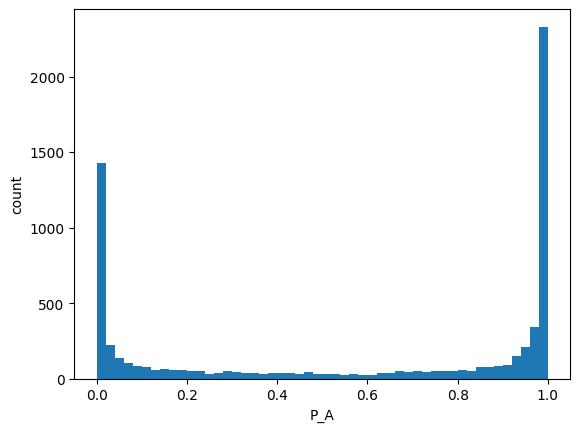

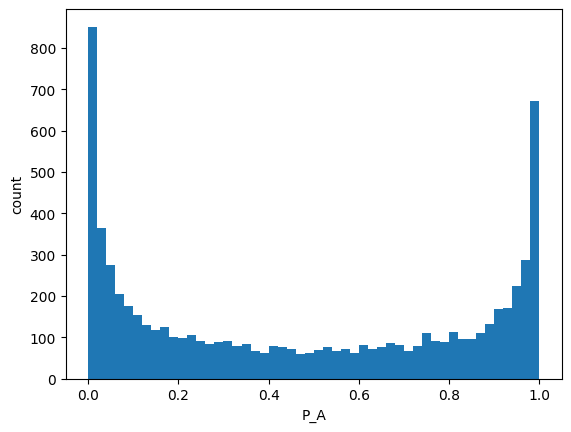

In [6]:
plt.hist(P_A, bins=50)
plt.xlabel("P_A")
plt.ylabel("count")
plt.show()
plt.hist(P_A2, bins=50)
plt.xlabel("P_A")
plt.ylabel("count")
plt.show()

In [7]:
# train = np.load("../data/processed/dataset_train_shortened.npz", allow_pickle=True)
# X_train = train["X"]
# y_train = train["y"]

# full = np.load("../data/processed/dataset_full.npz", allow_pickle=True)
# X_full  = full["X"]
# K0_full = full["K0"]


train = np.load("../data/processed/TRAIN_FULL.npz", allow_pickle=True)
X_train = train["X"]
y_train = train["y"]

full = np.load("../data/processed/FULL_CORRECT.npz", allow_pickle=True)
X_full  = full["X"]
K0_full = full["K0"]

full_k477 = np.load("../data/processed/477_NO_ROTATION.npz", allow_pickle=True)
k477_X = full_k477["X"]

In [8]:
k0_ref = 4.77
k4_ref = 1.178870


mask = (K0_full == k0_ref)
X_full_k477 = X_full[mask]
k477 = k477_X[::10]
print(k477.shape)
n0 = k477[:, 0]
n4 = k477[:, 3]

med0 = np.median(n0)
med4 = np.median(n4)


(6953, 30)


In [9]:
@dataclass(frozen=True)
class JackknifeResult:
    theta_hat: float
    theta_jack: float
    se: float
    block_count: int
    block_size: int

In [10]:
def reweighting_weights(
    n0,
    n4,
    *,
    k0,
    k4,
    k0_ref=4.77,
    k4_ref=1.178870,
):

    med0 = np.median(n0)
    med4 = np.median(n4)

    log_w = (
        (k0 - k0_ref) * (n0 - med0)
        - (k4 - k4_ref) * (n4 - med4)
    )

    log_w -= np.max(log_w)

    return np.exp(log_w)

In [11]:


# =============================================================================
# BASIC OBSERVABLES
# =============================================================================

def weighted_mean(probability, weights):

    return np.sum(weights * probability)  / np.sum(weights)


def weighted_variance(probability, weights):

    mean = weighted_mean(probability, weights)

    mean2 = np.sum(weights * probability**2)  / np.sum(weights)

    return mean2 - mean**2


def weighted_chi(probability, weights):

    mean = weighted_mean(probability, weights)

    if mean == 0:
        return 0.0

    return weighted_variance(probability, weights)  / mean

In [12]:
# =============================================================================
# MATHEMATICA-LIKE BLOCK JACKKNIFE
# =============================================================================

def block_jackknife(
    probability,
    weights,
    observable_fn,
    block_count,
):

    N = len(probability)

    block_size = N // block_count

    usable = block_size * block_count

    probability = probability[:usable]
    weights = weights[:usable]

    # contiguous physical blocks
    p_blocks = probability.reshape(block_count, block_size)
    w_blocks = weights.reshape(block_count, block_size)

    # full estimator
    theta_hat = observable_fn(probability, weights)

    replicates = np.zeros(block_count)

    # leave-one-block-out jackknife
    for i in range(block_count):

        mask = np.ones(block_count, dtype=bool)
        mask[i] = False

        p_jk = p_blocks[mask].ravel()
        w_jk = w_blocks[mask].ravel()

        replicates[i] = observable_fn(p_jk, w_jk)

    theta_bar = np.mean(replicates)

    theta_jack = theta_hat - (block_count - 1) * (theta_bar - theta_hat)

    variance = (
        (block_count - 1)
        * np.mean((replicates - theta_bar)**2)
    )

    se = np.sqrt(variance)

    return JackknifeResult(
        theta_hat=float(theta_hat),
        theta_jack=float(theta_jack),
        se=float(se),
        block_count=block_count,
        block_size=block_size,
    )



In [13]:

# =============================================================================
# CURVE
# =============================================================================

def reweighted_jackknife_curve_max_error(
    probability,
    n0,
    n4,
    k0_values,
    k4_values,
    *,
    block_counts=list(range(2, 21)) + list(range(30, 101, 10)),
):

    rows = []

    for k0, k4 in zip(k0_values, k4_values):

        weights = reweighting_weights(
            n0,
            n4,
            k0=k0,
            k4=k4,
        )

        best_mean = None
        best_var = None
        best_chi = None

        max_mean_err = -1
        max_var_err = -1
        max_chi_err = -1

        for B in block_counts:

            try:

                mean_res = block_jackknife(
                    probability,
                    weights,
                    weighted_mean,
                    B,
                )

                var_res = block_jackknife(
                    probability,
                    weights,
                    weighted_variance,
                    B,
                )

                chi_res = block_jackknife(
                    probability,
                    weights,
                    weighted_chi,
                    B,
                )

                if mean_res.se > max_mean_err:
                    max_mean_err = mean_res.se
                    best_mean = mean_res

                if var_res.se > max_var_err:
                    max_var_err = var_res.se
                    best_var = var_res

                if chi_res.se > max_chi_err:
                    max_chi_err = chi_res.se
                    best_chi = chi_res

            except:
                pass

        rows.append({
            "k0": k0,
            "k4": k4,

            "mean": best_mean.theta_hat,
            "mean_se": best_mean.se,

            "variance": best_var.theta_hat,
            "variance_se": best_var.se,

            "chi": best_chi.theta_hat,
            "chi_se": best_chi.se,
        })

    return pd.DataFrame(rows)

def reweighted_jackknife_curve(
    probability,
    n0,
    n4,
    k0_values,
    k4_values,
    *,
    block_count,
    k0_ref=4.77,
    k4_ref=1.178870,
):

    rows = []

    for k0, k4 in zip(k0_values, k4_values):

        weights = reweighting_weights(
            n0,
            n4,
            k0=k0,
            k4=k4,
            k0_ref=k0_ref,
            k4_ref=k4_ref,
        )

        mean_res = block_jackknife(
            probability,
            weights,
            weighted_mean,
            block_count,
        )

        var_res = block_jackknife(
            probability,
            weights,
            weighted_variance,
            block_count,
        )

        chi_res = block_jackknife(
            probability,
            weights,
            weighted_chi,
            block_count,
        )

        rows.append({
            "k0": k0,
            "k4": k4,

            "mean": mean_res.theta_hat,
            "mean_se": mean_res.se,

            "variance": var_res.theta_jack,
            "variance_se": var_res.se,

            "chi": chi_res.theta_hat,
            "chi_se": chi_res.se,
        })

    return pd.DataFrame(rows)




In [14]:
# =============================================================================
# BLOCK SCAN
# =============================================================================

def scan_block_sizes(
    probability,
    n0,
    n4,
    *,
    k0,
    k4,
    block_counts=list(range(2, 21)) + list(range(30, 101, 10))
):

    rows = []

    weights = reweighting_weights(
        n0,
        n4,
        k0=k0,
        k4=k4,
    )

    for B in block_counts:

        try:

            var_res = block_jackknife(
                probability,
                weights,
                weighted_variance,
                B,
            )

            rows.append({
                "B": B,
                "variance": var_res.theta_jack,
                "variance_se": var_res.se,
                "block_size": var_res.block_size,
            })

        except:
            pass

    return pd.DataFrame(rows)


def scan_block_errors(
    probability,
    n0,
    n4,
    *,
    k0,
    k4,
    block_counts=list(range(2, 21)) + list(range(30, 101, 10)),
):

    rows = []

    weights = reweighting_weights(
        n0,
        n4,
        k0=k0,
        k4=k4,
    )

    # optional diagnostic
    neff = (np.sum(weights) ** 2) / np.sum(weights ** 2)

    for B in block_counts:

        try:

            mean_res = block_jackknife(
                probability,
                weights,
                weighted_mean,
                B,
            )

            var_res = block_jackknife(
                probability,
                weights,
                weighted_variance,
                B,
            )

            chi_res = block_jackknife(
                probability,
                weights,
                weighted_chi,
                B,
            )

            rows.append({
                "B": B,

                "block_size": mean_res.block_size,

                "mean": mean_res.theta_hat,
                "mean_se": mean_res.se,

                "variance": var_res.theta_jack,
                "variance_se": var_res.se,

                "chi": chi_res.theta_hat,
                "chi_se": chi_res.se,

                "neff": neff,
            })

        except Exception:
            pass

    df = pd.DataFrame(rows)

    max_idx = df["variance_se"].idxmax()
    
    max_row = df.loc[max_idx]

    max_idx_err = df["mean_se"].idxmax()
    
    max_row_err = df.loc[max_idx_err]
    
    return {
        "table": df,
        "max_B_variance": int(max_row["B"]),
        "max_B_error": int(max_row_err["B"]),
        "max_error": float(max_row_err["mean_se"]),
        "max_error_variance": float(max_row["variance_se"]),
    }


In [15]:

scan = scan_block_sizes(
    P_A,
    n0,
    n4,
    k0=4.77,
    k4=1.178870,
)

display(scan[0:100])


curve = reweighted_jackknife_curve_max_error(
    P_A,
    n0,
    n4,
    k_dense,
    k4_dense,
)

reweightedP = curve[["k0", "mean", "mean_se"]].to_numpy()

reweightedVar = curve[
    ["k0", "variance", "variance_se"]
].to_numpy()

reweightedChi = curve[
    ["k0", "chi", "chi_se"]
].to_numpy()



,B,variance,variance_se,block_size
0,2,0.183599,0.002748,3476
1,3,0.183877,0.004835,2317
2,4,0.183919,0.003161,1738
3,5,0.183802,0.002958,1390
4,6,0.183791,0.003167,1158
5,7,0.183757,0.002644,993
6,8,0.183731,0.002861,869
7,9,0.183686,0.002508,772
8,10,0.183730,0.002532,695
9,11,0.183685,0.002312,632


4
0.0191856324535888
(27,)


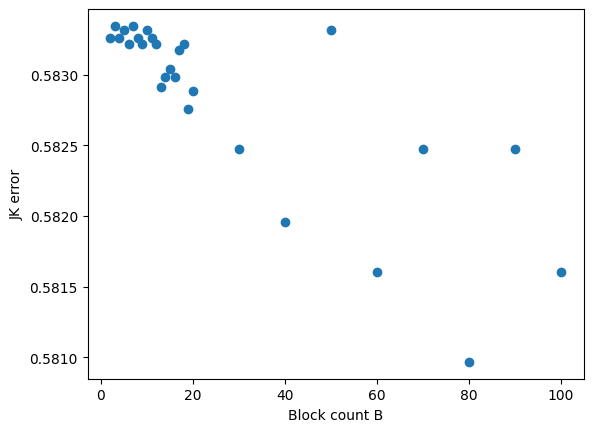

In [16]:
result1 = scan_block_errors(
    P_A,
    n0,
    n4,
    k0=4.77,
    k4=1.178870,
)

df_scan = result1["table"]

print(result1["max_B_error"])
print(result1["max_error"])
print(df_scan["variance"].shape)
plt.plot(df_scan["B"], df_scan["mean"], linestyle='None', marker='o')
plt.xlabel("Block count B")
plt.ylabel("JK error")
plt.show()

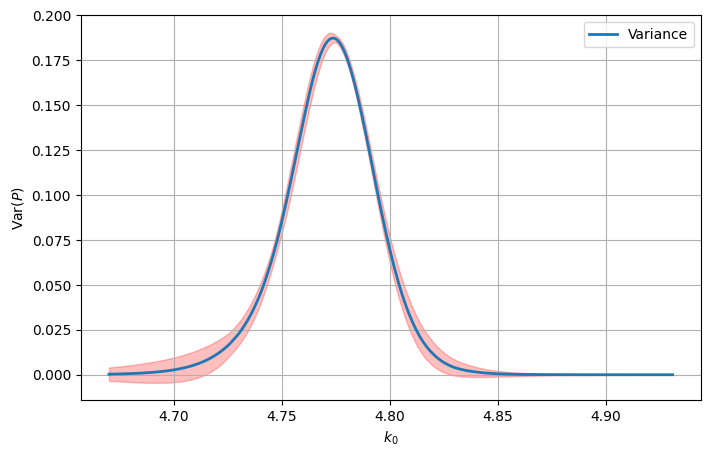

In [17]:
k = reweightedVar[:,0]
var = reweightedVar[:,1]
var_err = reweightedVar[:,2]

plt.figure(figsize=(8,5))

plt.plot(k, var, linewidth=2, label="Variance")

plt.fill_between(
    k,
    var - var_err,
    var + var_err,
    color="red",
    alpha=0.25
)

plt.xlabel(r"$k_0$")
plt.ylabel(r"$\mathrm{Var}(P)$")
plt.grid(True)
plt.legend()

plt.show()

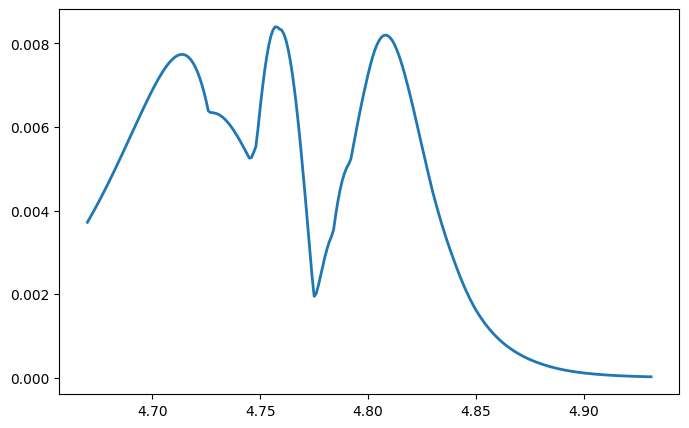

In [18]:
k = reweightedVar[:,0]
var = reweightedVar[:,1]
var_err = reweightedVar[:,2]

plt.figure(figsize=(8,5))

plt.plot(k, var_err, linewidth=2, label="Variance")

plt.show()

In [19]:
# meanP = []
# meanP2 = []

# for k0, k4 in zip(k_dense, k4_dense):

#     w = reweighting_weights(n0, n4, k0=k0, k4=k4)

#     m1 = np.sum(w * P_A) / np.sum(w)
#     m2 = np.sum(w * P_A**2) / np.sum(w)

#     meanP.append(m1)
#     meanP2.append(m2)

# meanP = np.array(meanP)
# meanP2 = np.array(meanP2)

# plt.plot(k_dense, meanP, label="mean")
# plt.plot(k_dense, meanP2, label="mean2")
# plt.legend()
# plt.show()

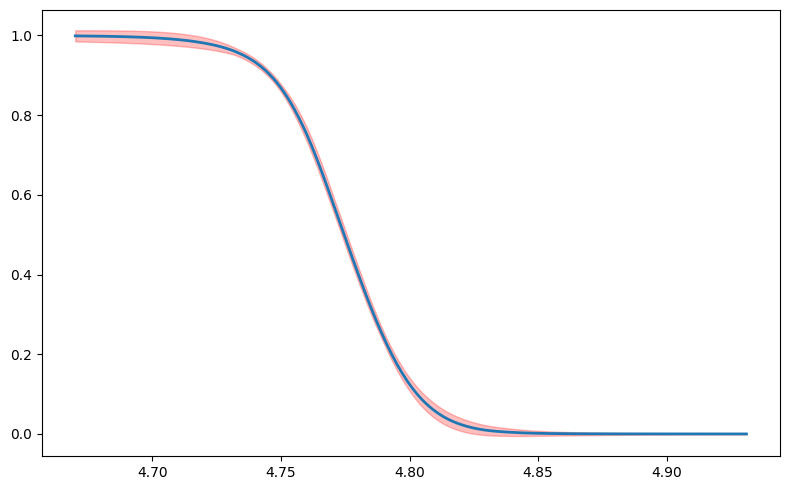

In [20]:
reweightedP = curve[["k0", "mean", "mean_se"]].to_numpy()
k = reweightedP[:,0]
mean = reweightedP[:,1]
err = reweightedP[:,2]

plt.figure(figsize=(8,5))

plt.plot(
    k,
    mean,
    linewidth=2,
    label="Reweighted mean probability"
)
plt.fill_between(k,
    mean - err,
    mean + err,
    color="red",
    alpha=0.25
)

plt.tight_layout()
plt.show()

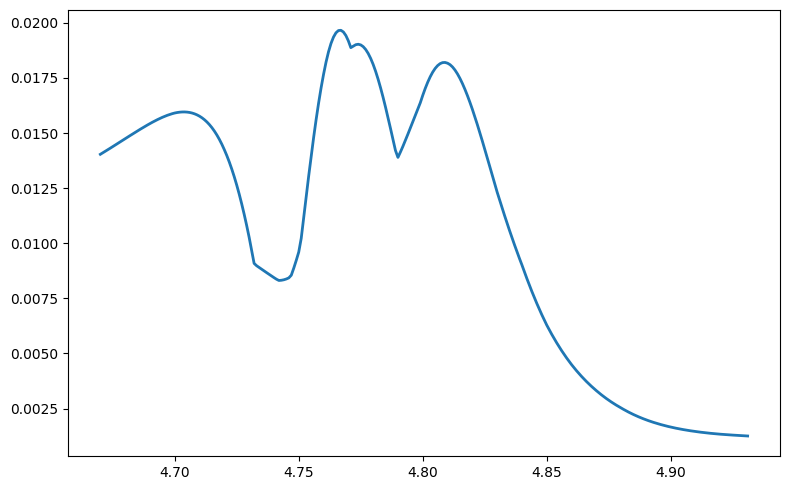

In [21]:
reweightedP = curve[["k0", "mean", "mean_se"]].to_numpy()
err = reweightedP[:,2]

plt.figure(figsize=(8,5))

plt.plot(
    k,
    err,
    linewidth=2,
)

plt.tight_layout()
plt.show()

In [22]:
from scipy.interpolate import interp1d
from scipy.optimize import brentq

f = interp1d(
    k,
    mean,
    kind="linear"
)

k_crit = brentq(
    lambda x: f(x) - 0.5,
    k.min(),
    k.max()
)

print("k0(P=0.5) =", k_crit)

print(mean.min(), mean.max())

idx = np.argmin(np.abs(mean - 0.5))

print(
    "closest point:",
    k[idx],
    mean[idx]
)

k0(P=0.5) = 4.774564191198927
5.908126063479121e-06 0.9989343201696045
closest point: 4.775 0.4920098216963161


In [23]:
from scipy.interpolate import interp1d

f_err = interp1d(
    k,
    err,
    kind="linear"
)

err_at_kcrit = float(f_err(k_crit))

print("k_crit =", k_crit)
print("P(k_crit) = 0.5")
print("error =", err_at_kcrit)

k_crit = 4.774564191198927
P(k_crit) = 0.5
error = 0.019012496348005396


In [24]:
# def reweighted_jackknife_curve_average(
#     probability,
#     n0,
#     n4,
#     k0_values,
#     k4_values,
#     *,
#     block_counts=list(range(2, 21)) + list(range(30, 101, 10)),
#     k0_ref=4.77,
#     k4_ref=1.178870,
# ):

#     rows = []

#     for k0, k4 in zip(k0_values, k4_values):

#         weights = reweighting_weights(
#             n0,
#             n4,
#             k0=k0,
#             k4=k4,
#             k0_ref=k0_ref,
#             k4_ref=k4_ref,
#         )

#         mean_list = []
#         mean_err_list = []

#         var_list = []
#         var_err_list = []

#         for B in block_counts:

#             try:

#                 mean_res = block_jackknife(
#                     probability,
#                     weights,
#                     weighted_mean,
#                     B,
#                 )

#                 var_res = block_jackknife(
#                     probability,
#                     weights,
#                     weighted_variance,
#                     B,
#                 )

#                 mean_list.append(mean_res.theta_hat)
#                 mean_err_list.append(mean_res.se)

#                 var_list.append(var_res.theta_jack)
#                 var_err_list.append(var_res.se)

#             except Exception:
#                 pass

#         rows.append({

#             "k0": k0,

#             "mean_P": np.mean(mean_list),
#             "mean_P_err": np.mean(mean_err_list),

#             "variance_P": np.mean(var_list),
#             "variance_P_err": np.mean(var_err_list),
#         })

#     return pd.DataFrame(rows)


In [25]:
# curve_max = curve[0:260]
# display(curve_max)


In [26]:
#ponizej sprawdzenie dla promotora w maju

In [27]:
# wyniki_srednia = np.loadtxt("./wyniki_srednia_P.txt")
# wyniki_wariancja = np.loadtxt("./wyniki_wariancja_P.txt")

# # print(wyniki_srednia)
# print(len(wyniki_wariancja))

In [28]:


# # =========================================================
# # YOUR RESULTS (RED)
# # =========================================================

# k0 = curve_max["k0"].to_numpy()

# mean_my = curve_max["mean"].to_numpy()
# mean_err_my = curve_max["mean_se"].to_numpy()

# var_my = curve_max["variance"].to_numpy()
# var_err_my = curve_max["variance_se"].to_numpy()


# # =========================================================
# # TXT RESULTS (GREEN)
# # =========================================================

# mean_txt = wyniki_srednia[:, 1]
# mean_err_txt = wyniki_srednia[:, 2]

# var_txt = wyniki_wariancja[:, 1]
# var_err_txt = wyniki_wariancja[:, 2]


# # =========================================================
# # 1. MEAN P
# # =========================================================

# plt.figure(figsize=(8,5))

# plt.plot(
#     k0,
#     mean_my,
#     'o',
#     color='red',
#     label='Mine'
# )

# plt.plot(
#     k0,
#     mean_txt,
#     'o',
#     color='green',
#     label='TXT'
# )

# plt.xlabel("K0")
# plt.ylabel("Mean P")

# plt.legend()
# plt.grid(True)
# plt.show()


# # =========================================================
# # 2. ERROR OF MEAN P
# # =========================================================

# plt.figure(figsize=(8,5))

# plt.plot(
#     k0,
#     mean_err_my,
#     'o',
#     color='red',
#     label='Mine'
# )

# plt.plot(
#     k0,
#     mean_err_txt,
#     'o',
#     color='green',
#     label='TXT'
# )

# plt.xlabel("K0")
# plt.ylabel("Mean P error")

# plt.legend()
# plt.grid(True)
# plt.show()


# # =========================================================
# # 3. VARIANCE
# # =========================================================

# plt.figure(figsize=(8,5))

# plt.plot(
#     k0,
#     var_my,
#     'o',
#     color='red',
#     label='Mine'
# )

# plt.plot(
#     k0,
#     var_txt,
#     'o',
#     color='green',
#     label='TXT'
# )

# plt.xlabel("K0")
# plt.ylabel("Variance")

# plt.legend()
# plt.grid(True)
# plt.show()


# # =========================================================
# # 4. VARIANCE ERROR
# # =========================================================

# plt.figure(figsize=(8,5))

# plt.plot(
#     k0,
#     var_err_my,
#     'o',
#     color='red',
#     label='Mine'
# )

# plt.plot(
#     k0,
#     var_err_txt,
#     'o',
#     color='green',
#     label='TXT'
# )

# plt.xlabel("K0")
# plt.ylabel("Variance error")

# plt.legend()
# plt.grid(True)
# plt.show()


In [29]:
# difference_table = pd.DataFrame({

#     "k0": curve_max["k0"],

#     # =====================================
#     # MEAN
#     # =====================================

#     "mean_diff":
#         curve_max["mean"].to_numpy()
#         - wyniki_srednia[:, 1],

#     "mean_se_diff":
#         curve_max["mean_se"].to_numpy()
#         - wyniki_srednia[:, 2],

#     # =====================================
#     # VARIANCE
#     # =====================================

#     "variance_diff":
#         curve_max["variance"].to_numpy()
#         - wyniki_wariancja[:, 1],

#     "variance_se_diff":
#         curve_max["variance_se"].to_numpy()
#         - wyniki_wariancja[:, 2],
# })

# display(difference_table)



In [30]:
# np.savetxt(
#     "difference.txt",
#     difference_table,
#     header="k0 mean_diff mean_se_diff variance_diff variance_se_diff",
# )
    